In [18]:
import os
import sys

import numpy as np
import pandas as pd
import warnings

warnings.filterwarnings("ignore")
sys.path.append(os.path.abspath(os.path.join("modelling", '../..')))

import matplotlib.pyplot as plt
import seaborn as sns

In [19]:
SEED = 42
PLOT_DPI = 100

TRAIN_DATA_FILE = "../data/preprocessed_skab_dataset_fe_train.csv"
SAVE_DATA_FILE = "../data/preprocessed_skab_dataset_train_undersampled.csv"

USE_FE = False

In [20]:
dataframe_train = pd.read_csv(TRAIN_DATA_FILE)

if not USE_FE:
    og_columns = ["Accelerometer1RMS", "Accelerometer2RMS", "Current", "Pressure", "Temperature", "Thermocouple", "Voltage", "Volume Flow RateRMS", "anomaly", "description"]
    dataframe_train = dataframe_train.drop(columns=[col for col in dataframe_train.columns if col not in og_columns])

dataframe_train

,Accelerometer1RMS,Accelerometer2RMS,Current,Pressure,Temperature,Thermocouple,Voltage,Volume Flow RateRMS,description,anomaly
0,0.219595,0.267058,2.972050,1.074847,88.9166,28.9319,227.339,127.0000,No Anomaly,0.0
1,0.028225,0.042124,1.432100,1.401284,68.6462,24.7640,245.677,32.9805,No Anomaly,0.0
2,0.214053,0.259569,2.228980,1.730701,88.2787,29.6790,227.822,127.0000,No Anomaly,0.0
3,0.255422,0.294430,2.998710,1.074847,86.2073,28.8126,232.379,126.0000,No Anomaly,0.0
4,0.081667,0.129274,1.561180,0.733489,87.2407,22.1358,234.136,77.0000,No Anomaly,0.0
...,...,...,...,...,...,...,...,...,...,...
34436,0.028173,0.041713,0.850848,0.745430,70.8238,25.2266,233.644,32.9921,No Anomaly,0.0
34437,0.080816,0.127709,1.614570,1.061416,87.1087,22.1432,230.259,76.9806,No Anomaly,0.0
34438,0.027668,0.041262,1.407610,1.401284,69.1150,24.8253,238.183,32.0000,No Anomaly,0.0
34439,0.209388,0.262548,2.756810,1.074847,88.4803,29.5671,235.927,127.6810,No Anomaly,0.0


In [21]:
def get_cluster_centers(df):
    """
    Get initial cluster centers for KMeans clustering.
    """
    init_center = dict()
    for idx in df.anomaly.unique():
        tmp = df.iloc[np.where(df.anomaly == idx)]
        tmp.drop(["anomaly", "description"], axis=1, inplace=True)
        tmp_mean = tmp.mean(axis=0)
        init_center[idx] = [val.item() for val in tmp_mean.values]
    # init_center = np.array(init_center)
    return init_center

In [22]:
def plot_pairplot(df, columns, title=None):
    """
    Plots a pairplot of the given dataframe with specified columns and hue.
    
    Args:
        dataframe (pd.DataFrame): The DataFrame containing the data.
    """
    plt.figure(figsize=(12, 12), dpi=PLOT_DPI)
    ax = sns.pairplot(
                        data = df, 
                        hue="description", 
                        hue_order=df["description"].value_counts().index, 
                        vars=columns, 
                        corner=True, 
                        plot_kws={'edgecolor': 'black', 'alpha': 0.6},
                        markers=['P', 'X', 'o', 'v', '^', '<', '>', 'h', 'H', 'D', 'd', 's', 'p', '8'],
    )
    sns.move_legend(ax, "center right", ncol=1, title="description", frameon=True)
    ax.fig.suptitle(title, y=1.02, weight="bold", fontsize=30) # Adjust y for vertical positioning

    plt.tight_layout(rect=[0, 0, 1, 0.96]) # Adjust layout to prevent title overlap

    # plt.savefig(f"../../datasets/Skoltech_Anomaly_Benchmark/plots/engineered_features/{title}.png", format="png")
    plt.show()

In [23]:
def get_distances_from_center(df, center, cluster_idx):
    """
    Calculate distances from the cluster center.
    
    Args:
        df (pd.DataFrame): DataFrame containing the data.
        center (np.ndarray): The cluster center.
        
    Returns:
        pd.Series: Distances from the cluster center.
    """

    tmp = df.iloc[np.where(df.anomaly == cluster_idx)]
    tmp_values = tmp.drop(columns=["anomaly", "description"]).to_numpy()
    distances = np.linalg.norm(tmp_values - center, axis=1)
    tmp["distances"] = distances / distances.max()
    return tmp

In [24]:
def plot_anomaly_heatmap(df, columns, threshold, anomaly_names, title=None):
    fig, axs = plt.subplots(14, 2, figsize=(20, 100), sharex=True, sharey=True, dpi=PLOT_DPI)
    plt.subplots_adjust(hspace=0.3)

    if title: plt.suptitle(title, fontsize=20)

    for idx, anomaly_name in anomaly_names.items():
        sns.heatmap(df.iloc[np.where(df.anomaly==idx)][columns].corr(), annot=True, fmt='.2f', linewidths=.7, ax=axs[int(idx), 0], cmap="coolwarm")
        axs[int(idx), 0].set_title(f"Heatmap of '{anomaly_name}'", weight="bold")

        sns.heatmap(df.iloc[np.where((df.anomaly==idx) & (df.distances<=threshold))][columns].corr(), annot=True, fmt='.2f', linewidths=.7, ax=axs[int(idx), 1], cmap="coolwarm")
        axs[int(idx), 1].set_title(f"Heatmap of '{anomaly_name}' (threshold={threshold})", weight="bold")


    plt.tight_layout(rect=[0, 0, 1, 0.96]) # Adjust layout to prevent title overlap
    plt.show()

In [25]:
cluster_centers = get_cluster_centers(dataframe_train)

tmps = list()
for idx, center in cluster_centers.items():
    print(idx, center)
    tmp = get_distances_from_center(dataframe_train, center, idx)
    tmps.append(tmp)

0.0 [0.12550283510482693, 0.15968235173898912, 1.7235859735901187, 1.1016766177058834, 80.24393433284577, 26.666230229156508, 229.64343807898587, 80.89147429302778]
12.0 [0.027368034340836015, 0.04070016548767417, 0.9706130587352625, 1.0853074711133952, 69.99261995712754, 25.01611922829582, 230.5964851018221, 29.624991318327975]
8.0 [0.25740182828282826, 0.2973350909090909, 2.363393936026936, 1.1322618047344157, 85.40168720538719, 29.299635016835023, 227.15155892255893, 40.34478107744108]
11.0 [0.08073642206759442, 0.13136548210735585, 1.5875731640159045, 1.0102385715611513, 87.4016717693837, 22.1145324055666, 229.82081908548707, 73.97008001988071]
13.0 [0.027604122939677143, 0.039844119881053526, 0.9650365751911639, 1.0666705884231034, 68.40216091758708, 24.221267289719627, 230.44404757858965, 30.408747153780798]
2.0 [0.5711841694915254, 0.6242205694915254, 2.4923016949152546, 1.1348742849261637, 88.4632661016949, 29.614537627118644, 229.83437966101692, 126.27997627118644]
1.0 [0.6317

In [26]:
dataframe_train_tmp = pd.concat(tmps, ignore_index=True)
dataframe_train_tmp

,Accelerometer1RMS,Accelerometer2RMS,Current,Pressure,Temperature,Thermocouple,Voltage,Volume Flow RateRMS,description,anomaly,distances
0,0.219595,0.267058,2.97205,1.074847,88.9166,28.9319,227.339,127.0000,No Anomaly,0.0,0.715625
1,0.028225,0.042124,1.43210,1.401284,68.6462,24.7640,245.677,32.9805,No Anomaly,0.0,0.789073
2,0.214053,0.259569,2.22898,1.730701,88.2787,29.6790,227.822,127.0000,No Anomaly,0.0,0.714068
3,0.255422,0.294430,2.99871,1.074847,86.2073,28.8126,232.379,126.0000,No Anomaly,0.0,0.694433
4,0.081667,0.129274,1.56118,0.733489,87.2407,22.1358,234.136,77.0000,No Anomaly,0.0,0.155850
...,...,...,...,...,...,...,...,...,...,...,...
34436,0.234111,0.298961,2.67178,1.074847,85.2649,30.1380,232.345,128.3120,Sharp Water Increase (Circuit),7.0,0.203519
34437,0.231709,0.301727,2.64041,1.730701,84.5624,30.0042,234.070,129.3120,Sharp Water Increase (Circuit),7.0,0.274327
34438,0.233409,0.303753,2.08954,1.074847,84.6937,30.1634,236.700,130.0000,Sharp Water Increase (Circuit),7.0,0.380446
34439,0.232973,0.300715,2.67952,1.074847,85.0247,30.1936,226.760,126.0000,Sharp Water Increase (Circuit),7.0,0.104732


In [27]:
anomaly_names = dict()
for desc, idx in zip(dataframe_train.description, dataframe_train.anomaly):
    anomaly_names[idx] = desc

In [28]:
columns = [
            "Accelerometer1RMS", 
            "Accelerometer2RMS", 
            "Current", 
            "Pressure", 
            "Temperature", 
            "Thermocouple", 
            "Voltage", 
            "Volume Flow RateRMS",
]

In [29]:
def get_undersampling_distances(df, anomaly_idx, thresholds, columns):
    og_corr = df.iloc[np.where(df.anomaly==anomaly_idx)][columns].corr().values.ravel()
    distances = list()
    for threshold in thresholds:
        tmp = dataframe_train_tmp.iloc[np.where(dataframe_train_tmp.distances <= threshold)]
        tmp_corr = tmp.iloc[np.where(tmp.anomaly==anomaly_idx)][columns].corr().values.ravel()
        distance = np.linalg.norm(og_corr - tmp_corr)
        distances.append(distance.item())

    return distances

In [30]:
thresholds = [0.3, 0.35, 0.4, 0.45, 0.5, 0.55, 0.6, 0.65, 0.7, 0.75, 0.8, 0.85, 0.9, 0.95, 1.0]

all_distances = dict()
for idx, _ in cluster_centers.items():
    distances = get_undersampling_distances(dataframe_train_tmp, idx, thresholds, columns)
    all_distances[idx.item()] = distances

# all_distances

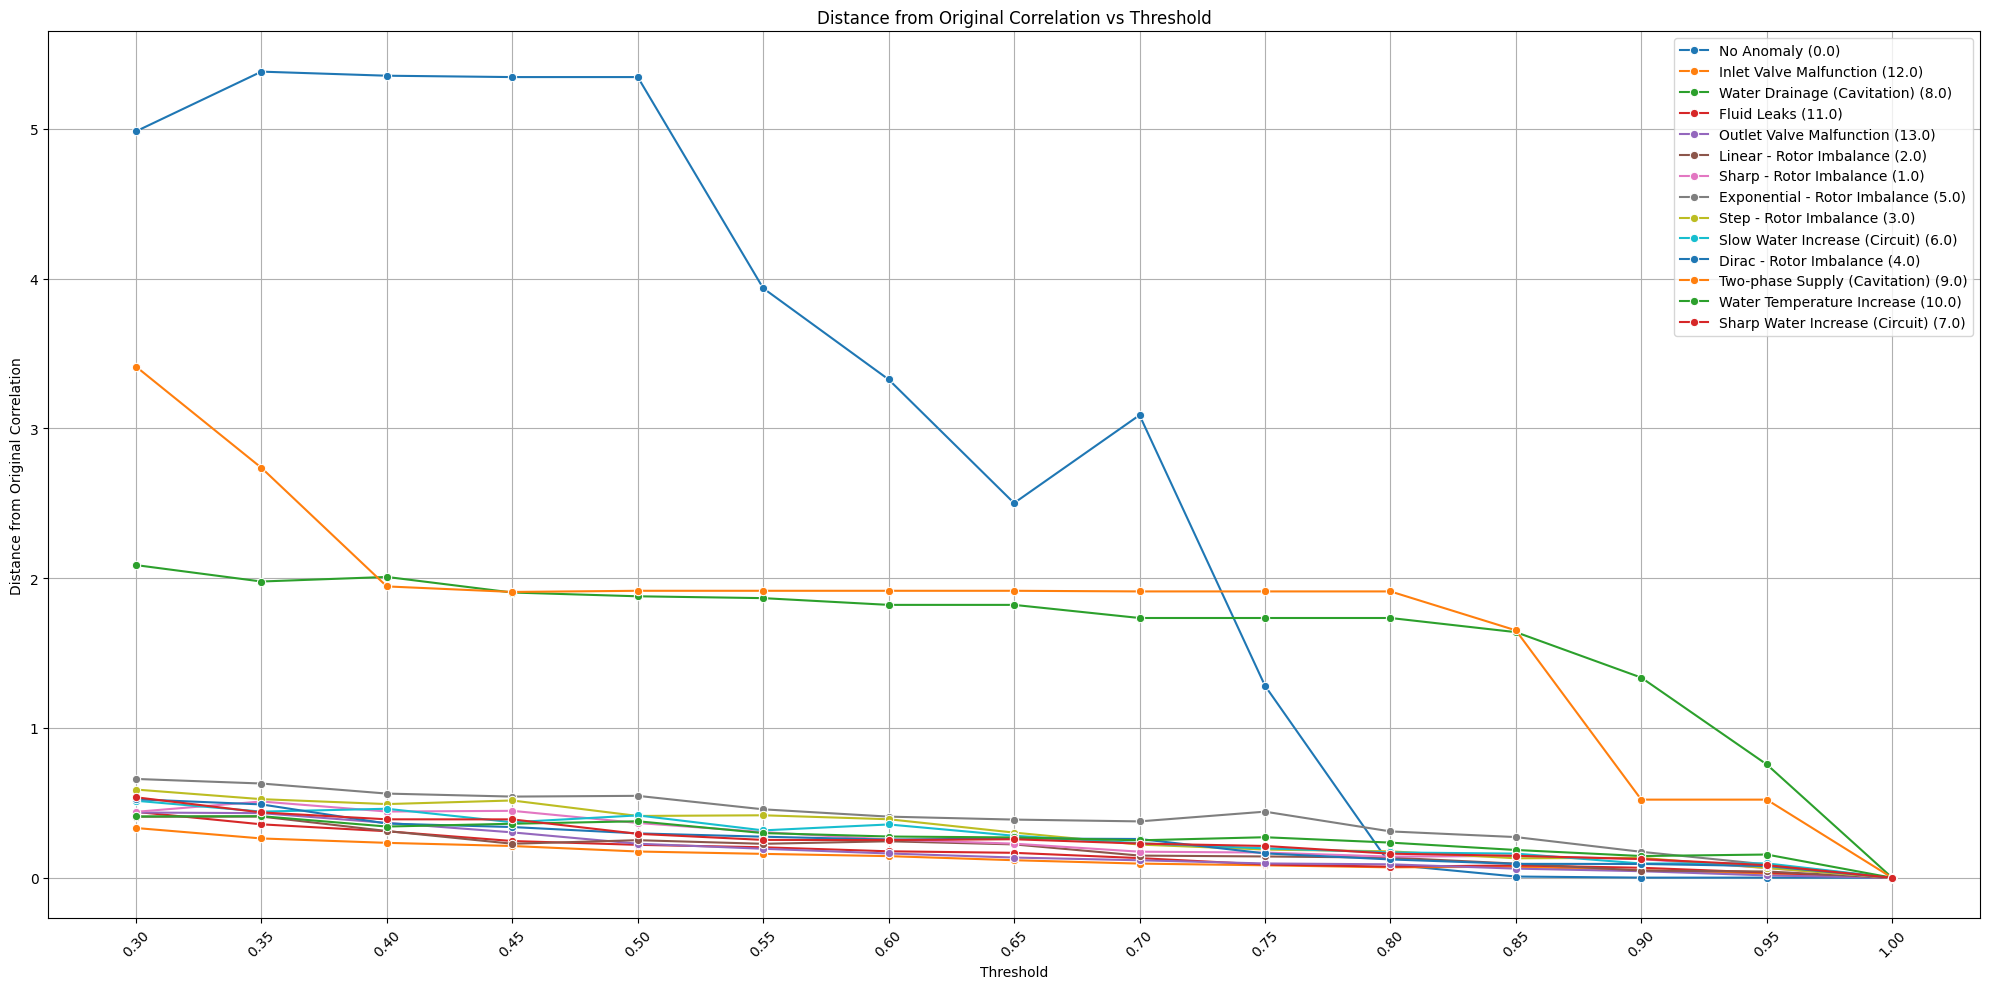

In [31]:
plt.figure(figsize=(20, 10), dpi=PLOT_DPI)

for idx, distances in all_distances.items():
    sns.lineplot(x=thresholds, y=distances, marker='o', label=f"{anomaly_names[idx]} ({idx})")

plt.xticks(ticks=thresholds, labels=[f"{i/100:.2f}" for i in range(30, 101, 5)], rotation=45)
plt.xlabel("Threshold")
plt.ylabel("Distance from Original Correlation")
plt.title("Distance from Original Correlation vs Threshold")
plt.grid()
plt.tight_layout()
plt.show()

In [32]:
dataframe_train_tmp.iloc[np.where((dataframe_train_tmp.distances <= 0.8) & (dataframe_train_tmp.anomaly != 100.0))]

,Accelerometer1RMS,Accelerometer2RMS,Current,Pressure,Temperature,Thermocouple,Voltage,Volume Flow RateRMS,description,anomaly,distances
0,0.219595,0.267058,2.97205,1.074847,88.9166,28.9319,227.339,127.0000,No Anomaly,0.0,0.715625
1,0.028225,0.042124,1.43210,1.401284,68.6462,24.7640,245.677,32.9805,No Anomaly,0.0,0.789073
2,0.214053,0.259569,2.22898,1.730701,88.2787,29.6790,227.822,127.0000,No Anomaly,0.0,0.714068
3,0.255422,0.294430,2.99871,1.074847,86.2073,28.8126,232.379,126.0000,No Anomaly,0.0,0.694433
4,0.081667,0.129274,1.56118,0.733489,87.2407,22.1358,234.136,77.0000,No Anomaly,0.0,0.155850
...,...,...,...,...,...,...,...,...,...,...,...
34435,0.232582,0.301550,2.55280,1.074847,84.6528,30.2489,243.604,125.6900,Sharp Water Increase (Circuit),7.0,0.660807
34436,0.234111,0.298961,2.67178,1.074847,85.2649,30.1380,232.345,128.3120,Sharp Water Increase (Circuit),7.0,0.203519
34437,0.231709,0.301727,2.64041,1.730701,84.5624,30.0042,234.070,129.3120,Sharp Water Increase (Circuit),7.0,0.274327
34438,0.233409,0.303753,2.08954,1.074847,84.6937,30.1634,236.700,130.0000,Sharp Water Increase (Circuit),7.0,0.380446


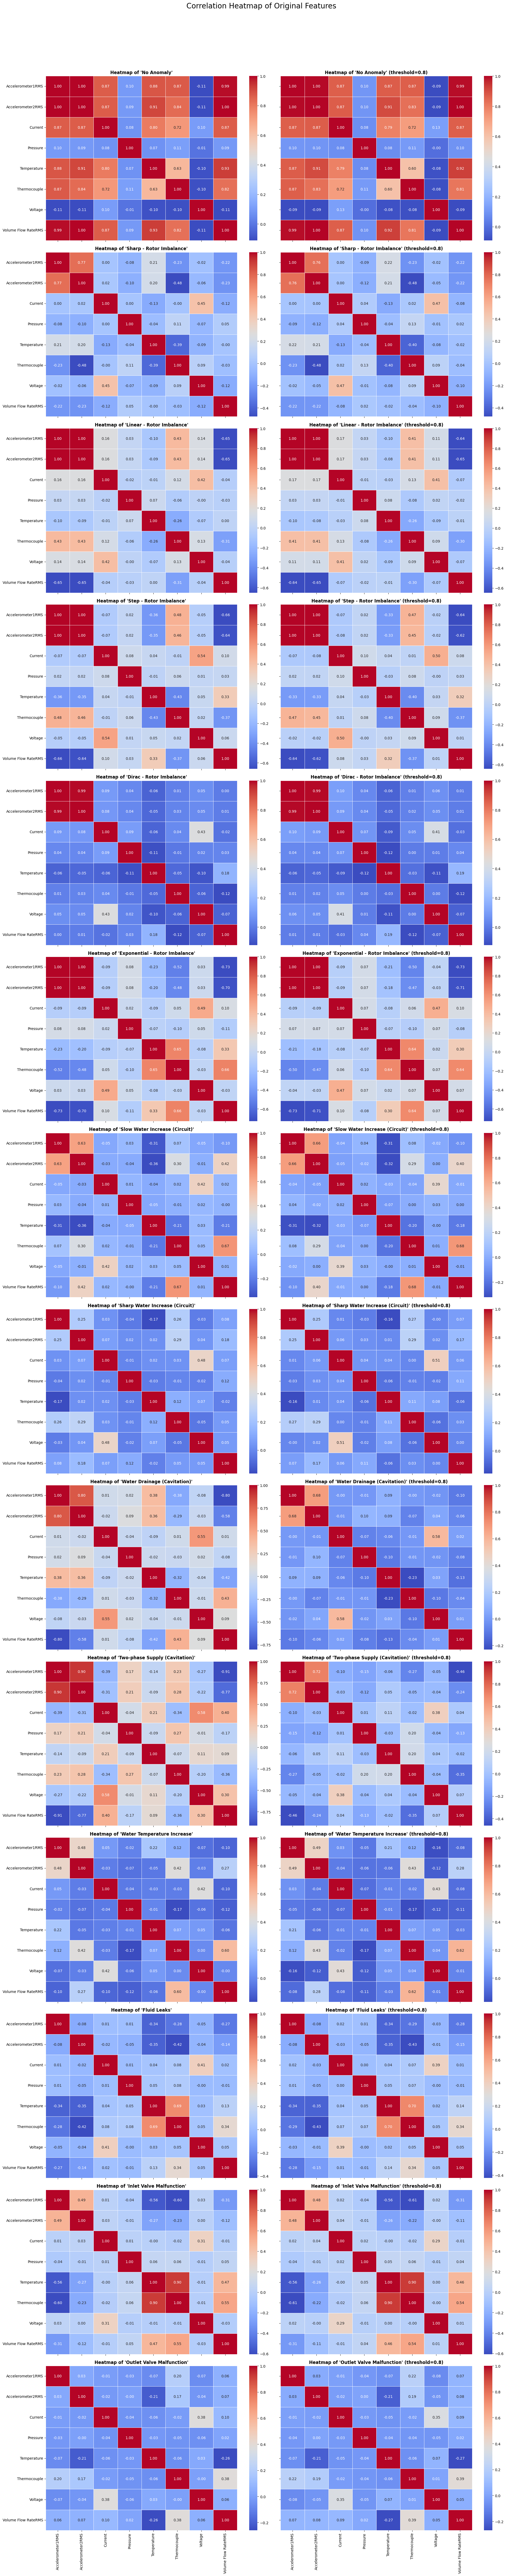

In [33]:
plot_anomaly_heatmap(dataframe_train_tmp, columns, 0.8, anomaly_names, title="Correlation Heatmap of Original Features")

In [34]:
tmp = dataframe_train_tmp.iloc[np.where(dataframe_train_tmp.distances <= 0.8)]

tmp.drop(columns=["distances"], inplace=True)
tmp.to_csv(SAVE_DATA_FILE, index=False)

In [35]:
# plot_anomaly_heatmap(dataframe_train_tmp.iloc[np.where(dataframe_train_tmp.distances <= 0.75)], columns, title="Correlation Between Parameters")

In [36]:
# plot_pairplot(tmp, columns, title="Bivariate Plot of Original Features")

# sns.heatmap(
#     tmp[columns].corr(),
#     annot=True,
#     fmt=".2f",
#     cmap="coolwarm",
#     linewidths=0.5,
#     linecolor='black'
# )
# plt.title("Correlation Heatmap of Original Features", fontsize=20, weight="bold")
# plt.show()

In [37]:
# threshold = 0.75

# plot_pairplot(tmp.iloc[np.where(tmp.distances <= threshold)], columns, title="Bivariate Plot of Original Features")

# sns.heatmap(
#     tmp.iloc[np.where(tmp.distances <= threshold)][columns].corr(),
#     annot=True,
#     fmt=".2f",
#     cmap="coolwarm",
#     linewidths=0.5,
#     linecolor='black'
# )
# plt.title("Correlation Heatmap of Original Features", fontsize=20, weight="bold")
# plt.show()